In [1]:
#!pip install pandas numpy matplotlib seaborn plotly scikit-learn xgboost

In [2]:
import pandas as pd
import numpy as np

In [3]:
# to visualize the dataset
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go

In [4]:
# To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

In [5]:
#for classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

In [6]:
from xgboost import XGBClassifier

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [9]:
# load the data from a csv file placed locally in your pc
df = pd.read_csv('input/heart_disease_uci.csv') # -> use your pc's file path to import the csv dataset
# print the first few rows of the dataframe
df.head()

,id,age,gender,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


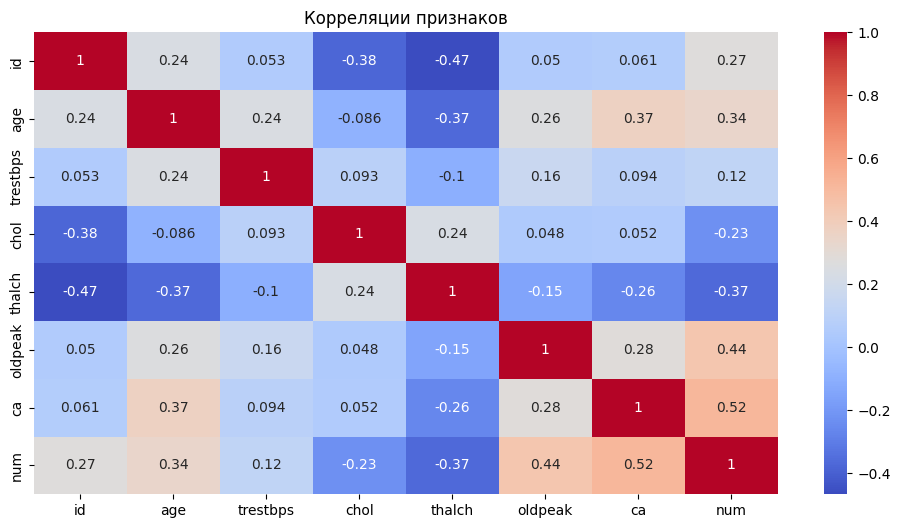

In [10]:
# Seaborn: корреляционная матрица
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Корреляции признаков')
plt.show()

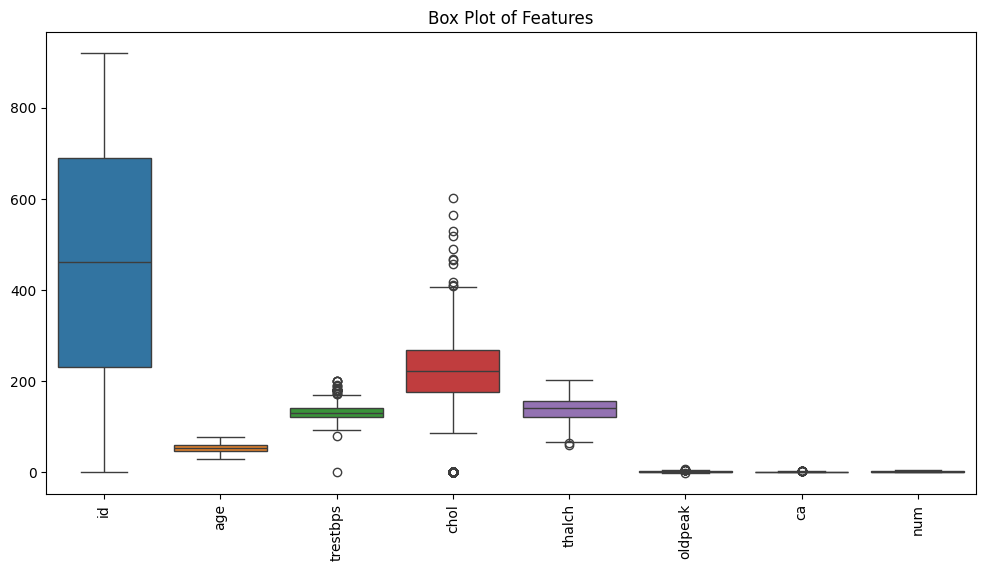

In [11]:
# Seaborn: boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.title('Box Plot of Features')
plt.show()

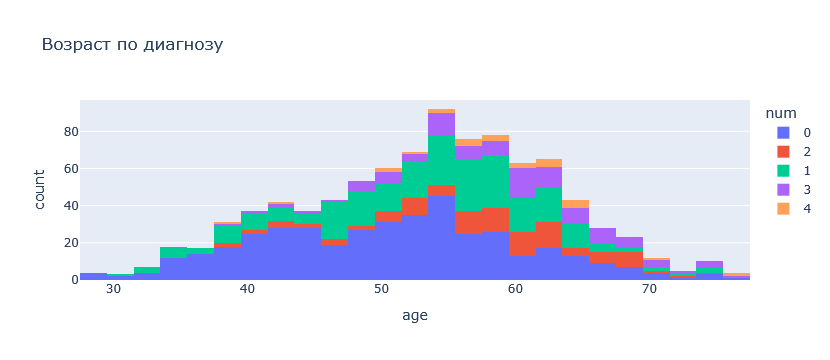

In [12]:
# Plotly Express: интерактивная гистограмма
px.histogram(df, x='age', color='num', title='Возраст по диагнозу').show()

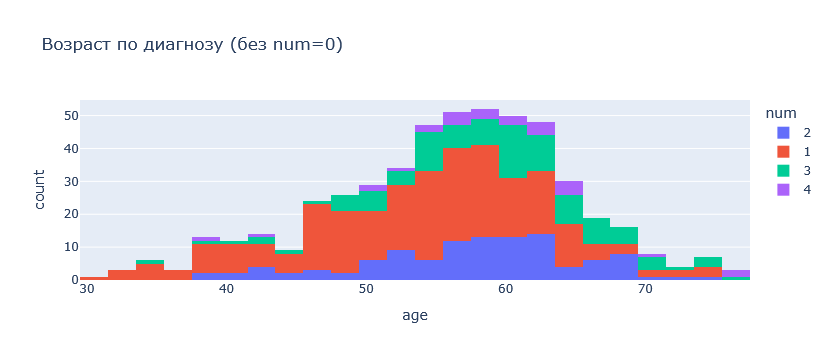

In [13]:
px.histogram(
    df.query('num != 0'),
    x='age',
    color='num',
    title='Возраст по диагнозу (без num=0)'
).show()

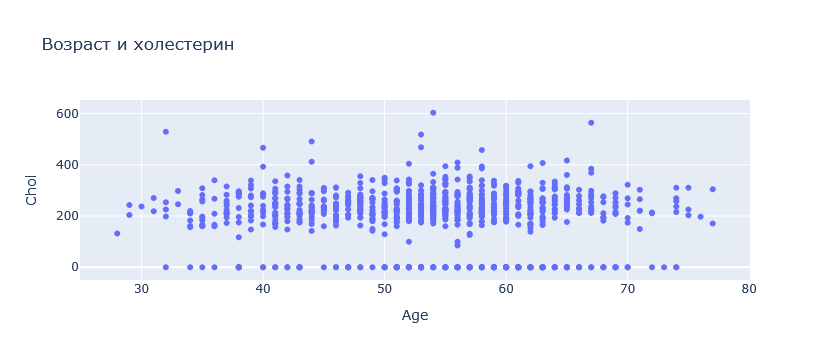

In [14]:
# Plotly Graph Objects: scatter
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['age'], y=df['chol'], mode='markers', name='Пациенты'))
fig.update_layout(title='Возраст и холестерин', xaxis_title='Age', yaxis_title='Chol')
fig.show()

In [15]:
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)

In [16]:
# le = LabelEncoder()
# y_encoded = le.fit_transform(y)

In [17]:
# imputer = KNNImputer(n_neighbors=5)
# X_imputed = imputer.fit_transform(X)

In [18]:
# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer
# imputer = IterativeImputer()
# X_imputed = imputer.fit_transform(X)

In [19]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
# param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 10]}
# grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
# grid.fit(X_train, y_train)
# best_model = grid.best_estimator_
# scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
# print(scores.mean())

# Типичный пайплайн:
1. Загрузить данные.
2. Разделить на `X` (признаки) и `y` (цель).
3. Разделить на train/test: `train_test_split`.
4. Обработать пропуски: `SimpleImputer` / `KNNImputer` / `IterativeImputer`.
5. Закодировать категории: `LabelEncoder` (для цели) или `OneHotEncoder` (для признаков).
6. Масштабировать числовые признаки: `StandardScaler` или `MinMaxScaler`.
7. Обучить модель.
8. Подобрать гиперпараметры: `GridSearchCV`.
9. Оценить: `cross_val_score`, метрики.

Всё это лучше объединять в `Pipeline` и `ColumnTransformer`, чтобы избежать утечки данных. Но в туториале эти импорты — просто заготовка инструментов.


In [22]:
# --- Загрузка данных ---
#df = pd.read_csv('input/heart_disease_uci.csv')

In [23]:
# --- X и y ---
target_col = 'num'
X = df.drop(columns=['id', target_col])
y = df[target_col]

In [24]:
# --- Списки колонок ---
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cat_cols = ['gender', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'ca']

In [25]:
# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

In [26]:
# --- Препроцессинг ---
preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

In [27]:
#preprocess

In [30]:
# --- Модель ---
model = Pipeline([
    ('preprocess', preprocess),
    ('classifier', XGBClassifier(
        objective='multi:softprob',
        num_class=5,
        eval_metric='mlogloss',
        random_state=0
    ))
])

In [32]:
#feature_names = model.named_steps['preprocess'].get_feature_names_out()

In [33]:
# --- Обучение ---
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [34]:
# --- Предсказания ---
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

In [35]:
# --- Оценка ---
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.87      0.78        82
           1       0.40      0.40      0.40        53
           2       0.36      0.18      0.24        22
           3       0.33      0.29      0.31        21
           4       0.00      0.00      0.00         6

    accuracy                           0.55       184
   macro avg       0.36      0.35      0.35       184
weighted avg       0.52      0.55      0.53       184

[[71  9  1  1  0]
 [22 21  2  7  1]
 [ 3 10  4  3  2]
 [ 2 10  3  6  0]
 [ 1  3  1  1  0]]
